In [1]:
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams['font.family'] = 'serif'

from scipy.optimize import curve_fit

import pickle

import schwingerModel as sim

In [2]:
def coshCorrel(nt, Energy, pivot,dimt):
    num = np.exp(-nt*Energy)+np.exp((nt-dimt)*Energy)
    denom = np.exp(-pivot*Energy)+np.exp((pivot-dimt)*Energy)
    return num/denom

In [2]:
with open('configs/50kSteps_a_2.pkl', 'rb') as f:
    a2 = pickle.load(f)

with open('configs/50kSteps_a_1.5.pkl', 'rb') as f:
    a15 = pickle.load(f)

with open('configs/50kSteps.pkl', 'rb') as f:
    a1 = pickle.load(f)

with open('configs/50kSteps_a_0.5.pkl', 'rb') as f:
    a5 = pickle.load(f)

with open('configs/20kSteps_a_0.33.pkl', 'rb') as f:
    a33 = pickle.load(f)

with open('configs/10kSteps_a_0.25.pkl', 'rb') as f:
    a25 = pickle.load(f)

In [3]:
bIn = 500
skp = 50

gamma = np.array([[1j,0],[0,-1j]])

correl_a2 =  sim.distillation.correlStats(a2, burnIn=bIn,autocorrSkip=skp)
correl_a15 =  sim.distillation.correlStats(a15, burnIn=bIn,autocorrSkip=skp)
correl_a1 =  sim.distillation.correlStats(a1, burnIn=bIn,autocorrSkip=skp)
correl_a5 =  sim.distillation.correlStats(a5, burnIn=bIn,autocorrSkip=skp)

correl_a33 =  sim.distillation.correlStats(a33, burnIn=500,autocorrSkip=skp)
correl_a25 =  sim.distillation.correlStats(a25, burnIn=100,autocorrSkip=10)


configs:   0%|          | 0/990 [00:00<?, ?it/s]

configs:   0%|          | 0/990 [00:00<?, ?it/s]

configs:   0%|          | 0/990 [00:00<?, ?it/s]

configs:   0%|          | 0/990 [00:00<?, ?it/s]

configs:   0%|          | 0/390 [00:00<?, ?it/s]

configs:   0%|          | 0/990 [00:00<?, ?it/s]

Text(0.5, 1.0, 'Correlation: $L_t = 32a$, $L_x=16a$, $m=0.2$, $\\Gamma=\\sigma_3$')

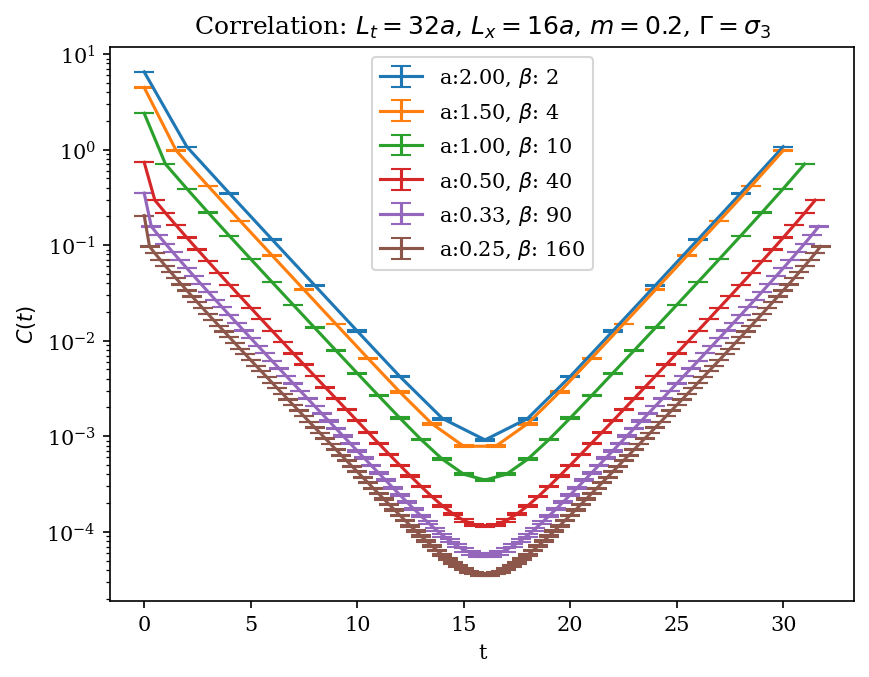

In [4]:
a2X = np.arange(stop = a1.dimt,step = a2.a)
a15X = np.arange(stop = a1.dimt-1,step = a15.a)
a1X = np.arange(stop = a1.dimt,step = a1.a)
a5X = np.arange(stop = a1.dimt,step = a5.a)
a33X = np.arange(stop = a1.dimt,step = a33.a)
a25X = np.arange(stop = a1.dimt,step = a25.a)

initInd = 0

plt.figure(dpi=150)
plt.errorbar(x=a2X[initInd:], y=correl_a2[0]/(a2.a**0), yerr=correl_a2[1]/(a2.a**0),capsize=5, label=rf"a:{a2.a:.2f}, $\beta$: {a2.beta:.0f}")
plt.errorbar(x=a15X[initInd:], y=correl_a15[0]/(a2.a**0), yerr=correl_a15[1]/(a2.a**0),capsize=5, label=rf"a:{a15.a:.2f}, $\beta$: {a15.beta:.0f}")
plt.errorbar(x=a1X[initInd:], y=correl_a1[0]/(a1.a**0), yerr=correl_a1[1]/(a1.a**0),capsize=5, label=rf"a:{a1.a:.2f}, $\beta$: {a1.beta:.0f}")
plt.errorbar(x=a5X[initInd:], y=correl_a5[0]/(a5.a**0), yerr=correl_a5[1]/(a5.a**0),capsize=5, label=rf"a:{a5.a:.2f}, $\beta$: {a5.beta:.0f}")
plt.errorbar(x=a33X[initInd:], y=correl_a33[0]/(a33.a**0), yerr=correl_a33[1]/(a33.a**0),capsize=5, label=rf"a:{a33.a:.2f}, $\beta$: {a33.beta:.0f}")
plt.errorbar(x=a25X[initInd:], y=correl_a25[0]/(a25.a**0), yerr=correl_a25[1]/(a25.a**0),capsize=5, label=rf"a:{a25.a:.2f}, $\beta$: {a25.beta:.0f}")

plt.semilogy()
plt.legend()
plt.xlabel("t")
plt.ylabel(r"$C(t)$")
plt.title(rf"Correlation: $L_t = 32a$, $L_x=16a$, $m={a2.fMass}$, $\Gamma=\sigma_3$")

In [5]:
a2_fitT = [3,13]
mass_a2 = sim.distillation.correlMassExtract(correl_a2,fitT=a2_fitT,diagCov=True)
a15_fitT = [6,16]
mass_a15 = sim.distillation.correlMassExtract(correl_a15,fitT=a15_fitT,diagCov=True)
a1_fitT = [10,25]
mass_a1 = sim.distillation.correlMassExtract(correl_a1,fitT=a1_fitT,diagCov=True)
a5_fitT = [20,45]
mass_a5 = sim.distillation.correlMassExtract(correl_a5,fitT=a5_fitT,diagCov=True)
a33_fitT = [30,70]
mass_a33 = sim.distillation.correlMassExtract(correl_a33,fitT=a33_fitT,diagCov=True)
a25_fitT = [45,85]
mass_a25 = sim.distillation.correlMassExtract(correl_a25,fitT=a25_fitT,diagCov=True)

In [6]:
scales = [.25,.33,.5,1,1.5,2]
masses = [mass_a25[0]/a25.a,mass_a33[0]/a33.a,mass_a5[0]/a5.a,mass_a1[0]/a1.a,mass_a15[0]/a15.a,mass_a2[0]/a2.a]
massErr = [mass_a25[1]/a25.a,mass_a33[1]/a33.a,mass_a5[1]/a5.a,mass_a1[1]/a1.a,mass_a15[1]/a15.a,mass_a2[1]/a2.a]

In [7]:
def quad(a, mCont, c1, c2):
    return c2*a**2+c1*a+mCont
coeffs, cErr = curve_fit(quad, scales, masses, sigma=massErr, absolute_sigma=True)

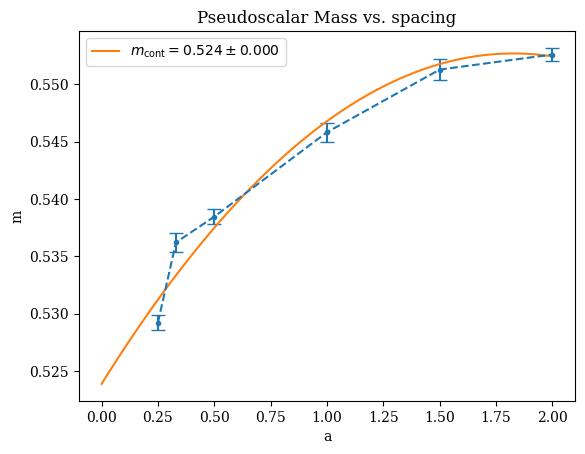

In [8]:
plt.errorbar(x=scales,y=masses, yerr= massErr,
                marker=".",ls="--",capsize=5)

aFine = np.linspace(0,2,100)
plt.plot(aFine, quad(aFine, *coeffs),label=rf"$m_\text{{cont}} = {coeffs[0]:.3f}\pm{cErr[0,0]:.3f}$")

plt.xlabel("a")
plt.ylabel("m")
plt.title("Pseudoscalar Mass vs. spacing")
plt.legend()

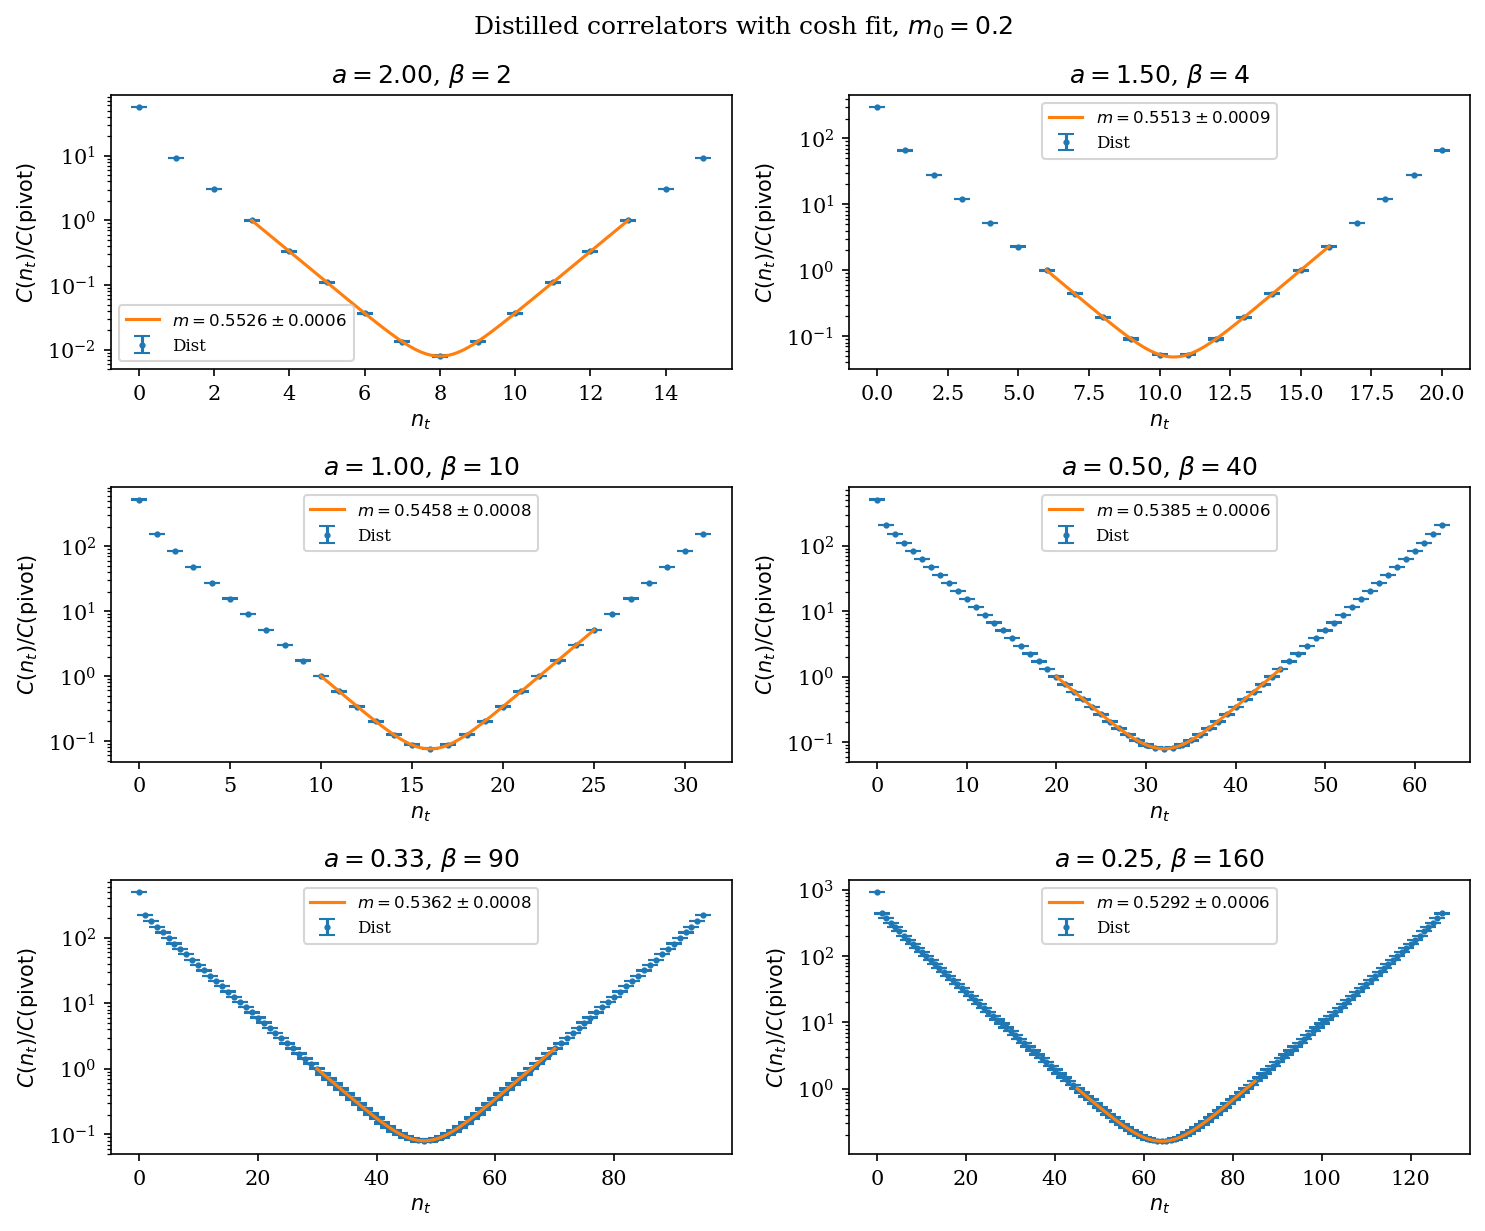

In [9]:
def coshCorrel(nt, Energy, pivot, dimt):
    num = np.exp(-nt * Energy) + np.exp((nt - dimt) * Energy)
    denom = np.exp(-pivot * Energy) + np.exp((pivot - dimt) * Energy)
    return num / denom

configs = [
    (a2,  correl_a2,  mass_a2,  a2_fitT[0],  a2_fitT[1]),
    (a15, correl_a15, mass_a15, a15_fitT[0],  a15_fitT[1]),
    (a1,  correl_a1,  mass_a1,  a1_fitT[0],  a1_fitT[1]),
    (a5,  correl_a5,  mass_a5,  a5_fitT[0], a5_fitT[1]),
    (a33, correl_a33, mass_a33, a33_fitT[0], a33_fitT[1]),
    (a25, correl_a25, mass_a25, a25_fitT[0], a25_fitT[1]),
]

fig, axes = plt.subplots(3, 2, figsize=(10, 8), dpi=150)

for ax, (model, correl, mass, pivot, fitEnd) in zip(axes.flat, configs):
    dimt = len(correl[0])

    nt_data = np.arange(dimt)
    nt_fine = np.linspace(pivot, fitEnd, 300)

    norm = correl[0][pivot]

    ax.errorbar(nt_data, correl[0] / norm, yerr=correl[1] / norm,
                fmt='.', capsize=4, markersize=4, label='Dist',zorder=0)
    ax.plot(nt_fine, coshCorrel(nt_fine, mass[0], pivot, dimt),
            label=rf'$m = {mass[0]/model.a:.4f} \pm {mass[1]/model.a:.4f}$',zorder=1)
    ax.set_yscale('log')
    ax.set_xlabel(r'$n_t$')
    ax.set_ylabel(r'$C(n_t) / C(\mathrm{pivot})$')
    ax.set_title(rf'$a = {model.a:.2f}$, $\beta = {model.beta:.0f}$')
    ax.legend(fontsize=8)

plt.tight_layout()
plt.suptitle(rf'Distilled correlators with cosh fit, $m_0 = {a1.fMass}$', y=1.02)
plt.show()